In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()  

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, FIGS_DIR
import results_comp

In [2]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


def load_multi_line_bin_results(
    results_comp,
    maps_dir,
    *,
    dataset_prefix="MUSE-M42",
    line_order=("H", "N", "O", "S", "Ar"),
    bin_levels=(0, 1, 2, 3, 4),
    read_header=True,
    fit_key="fit",
):
    """
    Load fit results for several emission lines and binning levels.

    It assumes file names like:

        MUSE-M42-H-bin0
        MUSE-M42-H-bin1
        MUSE-M42-N-bin0
        MUSE-M42-Ar-bin4

    Parameters
    ----------
    results_comp : module
        Module that contains load_line_bundle_mat.

    maps_dir : str or pathlib.Path
        Directory where the result files are stored.

    dataset_prefix : str
        Common prefix of the files. Default is "MUSE-M42".

    line_order : tuple or list of str
        Lines to load, in the desired plotting order.

    bin_levels : tuple or list of int
        Binning levels to load.

    read_header : bool
        Passed to results_comp.load_line_bundle_mat.

    fit_key : str
        Key used to access the fit table inside each loaded bundle.

    Returns
    -------
    data_in : list of dict
        Flat list with one dictionary per line/bin sample.

        Each entry has:
            line
            bin
            label
            file_name
            bundle
            fit
            fit_dict
            meta
    """

    data_in = []

    for line in line_order:
        for bin_level in bin_levels:
            file_name = f"{dataset_prefix}-{line}-bin{bin_level}"
            internal_name = f"{line}_bin{bin_level}_line"

            bundle = results_comp.load_line_bundle_mat(
                file_name,
                internal_name,
                maps_dir,
                read_header=read_header,
            )

            fit = bundle[fit_key]
            fit_dict = fit.to_dict(orient="list")

            entry = {
                "line": line,
                "bin": bin_level,
                "label": f"{line}{bin_level}",
                "file_name": file_name,
                "bundle": bundle,
                "fit": fit,
                "fit_dict": fit_dict,
                "meta": bundle.get("meta", {}),
            }

            data_in.append(entry)

    return data_in

In [3]:
#import plot_fit_params

data_in = load_multi_line_bin_results(
    results_comp,
    MAPS_DIR,
    dataset_prefix="MUSE-M42",
    line_order=("H", "N", "O", "S", "Ar"),
    bin_levels=(0, 1, 2, 3, 4),
    read_header=True,
)

## Mod

In [4]:
def plot_param_grid_lines_bins(
    data_in,
    *,
    params=("sig2", "r0", "m", "noise", "s0"),
    line_order=("H", "N", "O", "S", "Ar"),
    bin_levels=(0, 1, 2, 3, 4),
    xtick_labels=None,
    line_legend_labels=None,
    param_labels=None,
    param_titles=None,
    param_ylims=None,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    row_title_y=1.22,
    decimals=4,
    figsize=(15, 8),
    color_palette="Greys_d",
    markers=("o", "s", "^", "D", "P"),
    jitter=0.08,
    capsize=4,
    elinewidth=1.8,
    markersize=6,
    legend_fontsize=13,
    legend_title_fontsize=14,
    show_values=False,
    true=None,
    save=False,
    savepath="fit_parameters_grid.pdf",
):
    """
    Plot fit parameters for several lines and binning levels in a 3 x 2 grid.

    Layout
    ------
    First row:
        sig2, r0, m

    Second row:
        noise, s0, legend

    Parameters
    ----------
    data_in : list of dict
        Output from load_multi_line_bin_results.

        Each entry must contain:
            entry["line"]
            entry["bin"]
            entry["fit_dict"]

        where fit_dict has the format:
            {
                "sig2":  [value, upper_error, lower_error],
                "r0":    [value, upper_error, lower_error],
                "m":     [value, upper_error, lower_error],
                "s0":    [value, upper_error, lower_error],
                "noise": [value, upper_error, lower_error],
            }

    param_ylims : None or dict
        Custom y-axis ranges.

        Example:
            param_ylims = {
                "sig2": (0, 20),
                "r0": (0, 0.15),
                "m": (0.5, 2.0),
                "noise": (0, 2),
                "s0": (0, 0.02),
            }

    row_titles : tuple, list, or None
        Titles for the first and second row.

        Example:
            row_titles=("Physical parameters", "Nuisance parameters")

        If None, no row titles are added.
    """

    import numpy as np
    import seaborn as sns
    from matplotlib import pyplot as plt

    if len(data_in) == 0:
        raise ValueError("data_in is empty.")

    # ------------------------------------------------------------
    # Colors and markers
    # ------------------------------------------------------------
    colors = sns.color_palette(
        color_palette,
        n_colors=len(line_order),
    )[::-1]

    color_map = {
        line: colors[i]
        for i, line in enumerate(line_order)
    }

    marker_map = {
        line: markers[i % len(markers)]
        for i, line in enumerate(line_order)
    }

    # Symmetric jitter offsets centered around zero
    if len(line_order) > 1:
        jitter_offsets = np.linspace(
            -jitter,
            jitter,
            len(line_order),
        )
    else:
        jitter_offsets = np.array([0.0])

    jitter_map = {
        line: jitter_offsets[i]
        for i, line in enumerate(line_order)
    }

    # ------------------------------------------------------------
    # Custom x-axis labels
    # ------------------------------------------------------------
    if xtick_labels is None:
        xtick_labels_final = [f"bin{b}" for b in bin_levels]

    elif isinstance(xtick_labels, dict):
        xtick_labels_final = [
            xtick_labels.get(b, str(b))
            for b in bin_levels
        ]

    elif isinstance(xtick_labels, (list, tuple)):
        if len(xtick_labels) != len(bin_levels):
            raise ValueError(
                "If xtick_labels is a list/tuple, it must have the same "
                "length as bin_levels."
            )

        xtick_labels_final = list(xtick_labels)

    else:
        raise TypeError(
            "xtick_labels must be None, a list/tuple, or a dictionary."
        )

    # ------------------------------------------------------------
    # Custom legend labels for emission lines
    # ------------------------------------------------------------
    if line_legend_labels is None:
        line_legend_labels_final = {
            line: line
            for line in line_order
        }

    elif isinstance(line_legend_labels, dict):
        line_legend_labels_final = {
            line: line_legend_labels.get(line, line)
            for line in line_order
        }

    elif isinstance(line_legend_labels, (list, tuple)):
        if len(line_legend_labels) != len(line_order):
            raise ValueError(
                "If line_legend_labels is a list/tuple, it must have the same "
                "length as line_order."
            )

        line_legend_labels_final = {
            line: label
            for line, label in zip(line_order, line_legend_labels)
        }

    else:
        raise TypeError(
            "line_legend_labels must be None, a list/tuple, or a dictionary."
        )

    # ------------------------------------------------------------
    # Parameter titles and y-axis labels
    # ------------------------------------------------------------
    default_param_titles = {
        "sig2": r"$\sigma^2$ value",
        "r0": r"$r_0$ value",
        "m": r"$m$ value",
        "noise": r"$B_\mathrm{noise}$ value",
        "s0": r"$s_0$ value",
    }

    default_param_labels = {
        "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
        "r0": r"$r_0$ [pc]",
        "m": r"$m$",
        "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
        "s0": r"$s_0$ [pc]",
    }

    if param_titles is None:
        param_titles_final = default_param_titles
    else:
        param_titles_final = {
            **default_param_titles,
            **param_titles,
        }

    if param_labels is None:
        param_labels_final = default_param_labels
    else:
        param_labels_final = {
            **default_param_labels,
            **param_labels,
        }

    # ------------------------------------------------------------
    # Y-axis limits
    # ------------------------------------------------------------
    if param_ylims is None:
        param_ylims_final = {}
    elif isinstance(param_ylims, dict):
        param_ylims_final = param_ylims
    else:
        raise TypeError("param_ylims must be None or a dictionary.")

    # ------------------------------------------------------------
    # Convert true/reference values to a dictionary
    # ------------------------------------------------------------
    if true is None:
        true_map = {}

    elif isinstance(true, dict):
        true_map = true

    elif isinstance(true, (list, tuple)):
        true_keys = ["sig2", "r0", "m"]
        true_map = {
            key: value
            for key, value in zip(true_keys, true)
        }

    else:
        raise TypeError("true must be None, a dict, list, or tuple.")

    # ------------------------------------------------------------
    # Build lookup table
    # lookup[(line, bin)] = fit_dict
    # ------------------------------------------------------------
    lookup = {}

    for entry in data_in:
        line = entry["line"]
        bin_level = entry["bin"]
        lookup[(line, bin_level)] = entry["fit_dict"]

    # ------------------------------------------------------------
    # Figure layout
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        2,
        3,
        figsize=figsize,
        sharex=False,
    )

    axes = axes.ravel()

    param_to_axis = {
        "sig2": axes[0],
        "r0": axes[1],
        "m": axes[2],
        "noise": axes[3],
        "s0": axes[4],
    }

    # ------------------------------------------------------------
    # Main plotting loop
    # ------------------------------------------------------------
    for param in params:
        if param not in param_to_axis:
            continue

        ax = param_to_axis[param]

        for line in line_order:
            x_plot = []
            y_values = []
            yerr_lower = []
            yerr_upper = []

            for bin_level in bin_levels:
                key = (line, bin_level)

                if key not in lookup:
                    continue

                fit_dict = lookup[key]

                if param not in fit_dict:
                    continue

                value = round(float(fit_dict[param][0]), decimals)
                upper = max(0.0, round(float(fit_dict[param][1]), decimals))
                lower = max(0.0, round(float(fit_dict[param][2]), decimals))

                x_plot.append(bin_level + jitter_map[line])
                y_values.append(value)
                yerr_upper.append(upper)
                yerr_lower.append(lower)

            if len(x_plot) == 0:
                continue

            ax.errorbar(
                x_plot,
                y_values,
                yerr=[yerr_lower, yerr_upper],
                fmt=marker_map[line],
                color=color_map[line],
                markerfacecolor=color_map[line],
                markeredgecolor="black",
                markeredgewidth=0.6,
                markersize=markersize,
                capsize=capsize,
                elinewidth=elinewidth,
                linestyle="none",
                label=line_legend_labels_final[line],
            )

            if show_values:
                for x, y in zip(x_plot, y_values):
                    ax.text(
                        x,
                        y,
                        f"{y:.{decimals}f}",
                        ha="center",
                        va="bottom",
                        fontsize=8,
                    )

        if param in true_map and true_map[param] is not None:
            ax.axhline(
                true_map[param],
                color="red",
                linestyle="--",
                linewidth=1.2,
                label="Reference",
            )

        ax.set_title(param_titles_final.get(param, f"{param} value"))
        ax.set_ylabel(param_labels_final.get(param, param))
        ax.grid(alpha=0.3)

        # Apply custom y-axis range if requested
        if param in param_ylims_final and param_ylims_final[param] is not None:
            ax.set_ylim(param_ylims_final[param])

    # ------------------------------------------------------------
    # Common x-axis formatting
    # ------------------------------------------------------------
    for ax in axes[:5]:
        ax.set_xticks(list(bin_levels))
        ax.set_xticklabels(xtick_labels_final, rotation=45)
        ax.set_xlabel("Binning level")

        ax.set_xlim(
            min(bin_levels) - 0.5,
            max(bin_levels) + 0.5,
        )

    # ------------------------------------------------------------
    # Row titles
    # ------------------------------------------------------------
    if row_titles is not None:
        if len(row_titles) != 2:
            raise ValueError("row_titles must contain exactly two entries.")

        axes[1].annotate(
            row_titles[0],
            xy=(0.5, row_title_y),
            xycoords="axes fraction",
            ha="center",
            va="center",
            fontsize=row_title_fontsize,
            fontweight="bold",
        )

        axes[4].annotate(
            row_titles[1],
            xy=(0.5, row_title_y),
            xycoords="axes fraction",
            ha="center",
            va="center",
            fontsize=row_title_fontsize,
            fontweight="bold",
        )

    # ------------------------------------------------------------
    # Legend in the empty (2, 3) panel
    # ------------------------------------------------------------
    legend_ax = axes[5]
    legend_ax.axis("off")

    handles, legend_labels = [], []

    for ax in axes[:5]:
        handles, legend_labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            break

    if len(handles) > 0:
        legend_ax.legend(
            handles,
            legend_labels,
            loc="center",
            frameon=False,
            title="Line",
            fontsize=legend_fontsize,
            title_fontsize=legend_title_fontsize,
            markerscale=1.4,
            handlelength=1.5,
            labelspacing=1.1,
        )

    fig.tight_layout()

    if save:
        fig.savefig(savepath, bbox_inches="tight")

    return fig, axes

In [5]:
sns.set_context("talk")


line_legend_labels = {
    "H": r"H$\alpha$ 6563",
    "N": r"[N II] 6583",
    "O": r"[O III] 5007",
    "S": r"[S III] 9069",
    "Ar": r"[Ar III] 7136",
}

param_ylims = {
    "sig2": (0, 12),
    "r0": (0, 0.08),
    "m": (0.5, 1.5),
    "noise": (-1, 15),
    "s0": (0, 0.0035),
}

param_labels = {
    "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
    "r0": r"$r_0$ [pc]",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
    "s0": r"$s_0$ [pc]",
}

param_titles = {
    "sig2": r"$\sigma^2$ vs binning level",
    "r0": r"$r_0$ vs binning level",
    "m": r"$m$ vs binning level",
    "noise": r"$B_\mathrm{noise}$ vs binning level",
    "s0": r"$s_0$ vs binning level",
}


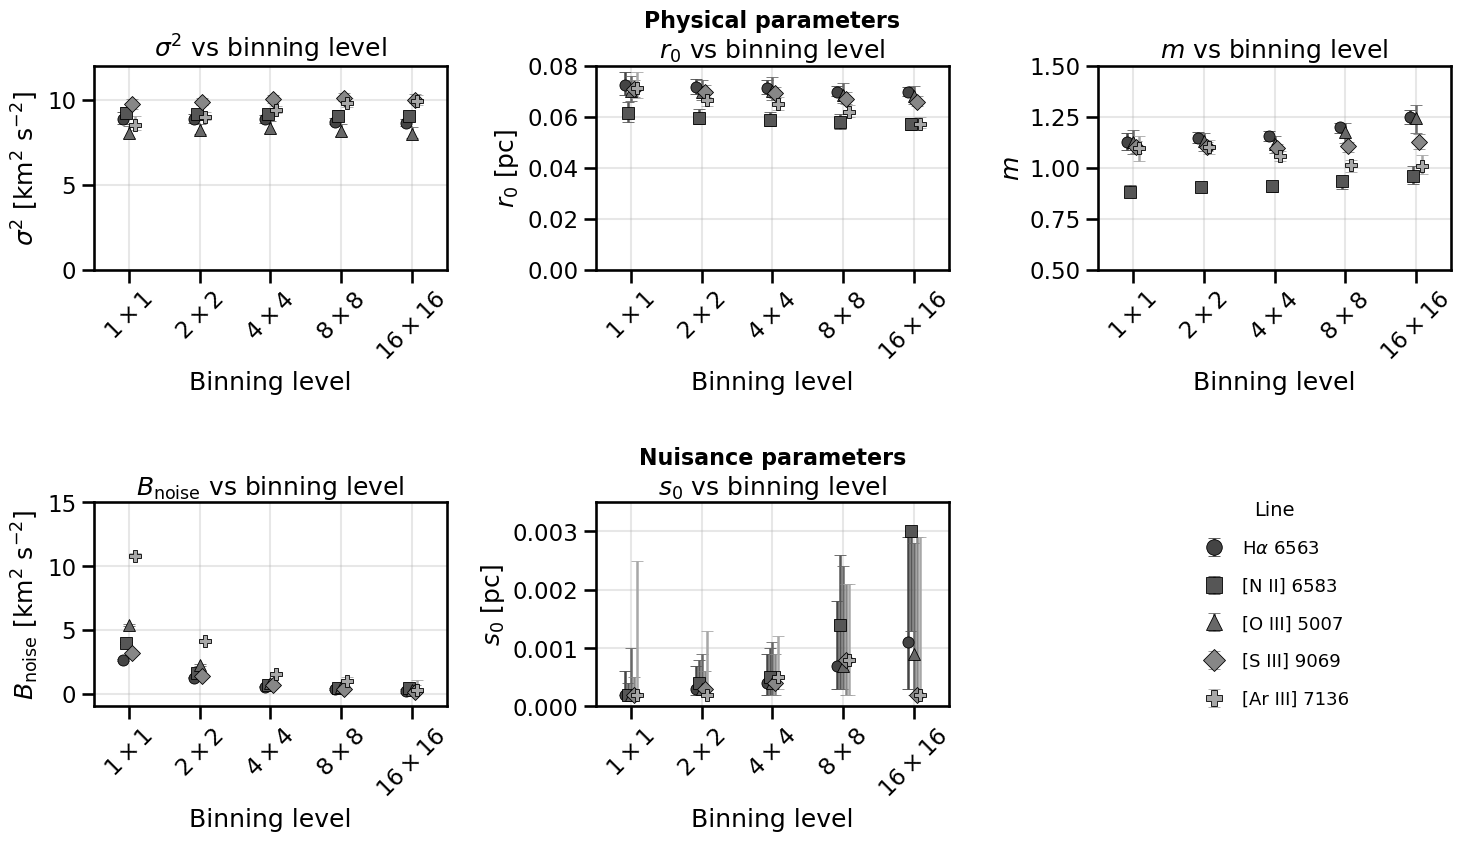

In [6]:

fig, axes = plot_param_grid_lines_bins(
    data_in,
    line_order=("H", "N", "O", "S", "Ar"),
    bin_levels=(0, 1, 2, 3, 4),
    xtick_labels=[r"$1 \times 1$", 
                  r"$2 \times 2$", 
                  r"$4 \times 4$",
                  r"$8 \times 8$", 
                  r"$16 \times 16$"],
    line_legend_labels=line_legend_labels,
    param_labels=param_labels,
    param_titles=param_titles,
    param_ylims=param_ylims,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    decimals=4,
    figsize=(15, 9),
    markersize=8,
    jitter=0.08,
    save=True,
    savepath="fit_parameters_grid_2.pdf",
)

Seeing in arcsec

In [7]:
data_in[0]['meta']['PC']

0.001987736092549097

In [8]:
data_in[0]['fit']

,sig2,r0,m,s0,noise
0,8.884553,0.072300,1.128437,0.000199,2.614909
1,0.398837,0.005180,0.041207,0.000443,0.075701
2,0.310497,0.003908,0.041804,-0.000004,0.044328


In [9]:
(data_in[0]['fit'].s0/data_in[0]['meta']['PC'])*2.35

0    0.235000
1    0.523510
2   -0.005034
Name: s0, dtype: float64

In [10]:
len(data_in)

25

In [11]:
for i in range(len(data_in)):
    data_in[i]['fit']['s0'] = (
        (data_in[i]['fit']['s0'] / data_in[i]['meta']['PC']) * 2.35).clip(lower=0)

In [12]:
data_in[0]['fit']

,sig2,r0,m,s0,noise
0,8.884553,0.072300,1.128437,0.23500,2.614909
1,0.398837,0.005180,0.041207,0.52351,0.075701
2,0.310497,0.003908,0.041804,0.00000,0.044328


In [13]:
param_ylims = {
    "sig2": (0, 12),
    "r0": (0, 0.08),
    "m": (0.5, 1.5),
    "noise": (-1, 15),
    "s0": (0, 0.0035),
}

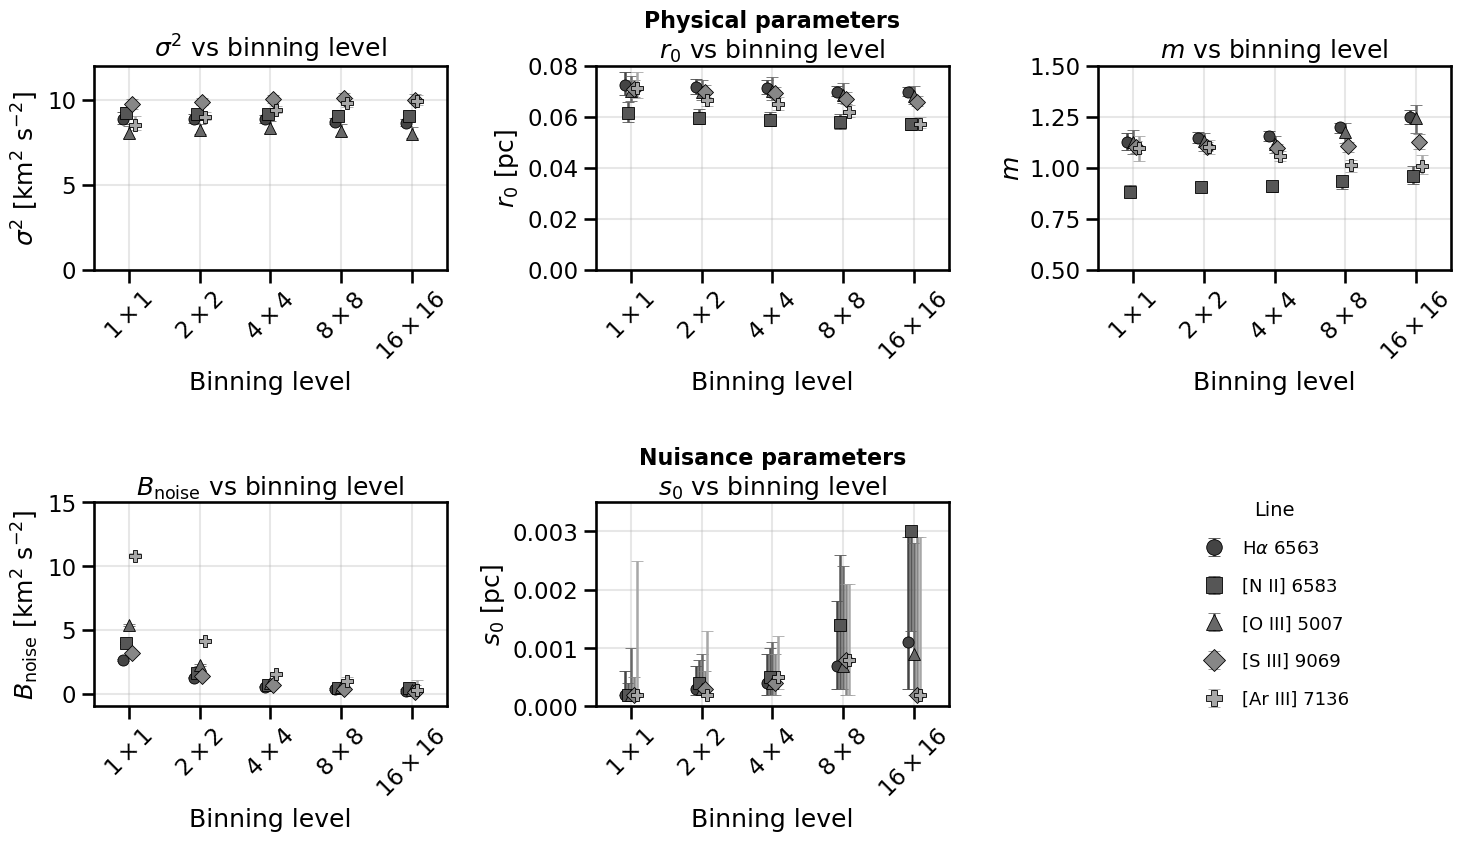

In [14]:
fig, axes = plot_param_grid_lines_bins(
    data_in,
   # params=("sig2", "r0", "m", "noise", "s0_"),
    line_order=("H", "N", "O", "S", "Ar"),
    bin_levels=(0, 1, 2, 3, 4),
    xtick_labels=[r"$1 \times 1$", 
                  r"$2 \times 2$", 
                  r"$4 \times 4$",
                  r"$8 \times 8$", 
                  r"$16 \times 16$"],
    line_legend_labels=line_legend_labels,
    param_labels=param_labels,
    param_titles=param_titles,
    param_ylims=param_ylims,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    decimals=4,
    figsize=(15, 9),
    markersize=8,
    jitter=0.08,
    save=False,
    savepath="fit_parameters_grid_2_new.pdf",
)

In [15]:
for i in range(len(data_in)):
    pc = data_in[i]['meta']['PC']
    scale = 2.35 / pc

    old_value = data_in[i]['fit_dict']['s0'][0]
    old_upper = data_in[i]['fit_dict']['s0'][1]
    old_lower = data_in[i]['fit_dict']['s0'][2]

    new_value = max(0, old_value * scale)
    new_upper = old_upper * scale
    new_lower = old_lower * scale

    data_in[i]['fit_dict']['s0'] = [
        new_value,
        new_upper,
        new_lower,
    ]

In [16]:

param_labels = {
    "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
    "r0": r"$r_0$ [pc]",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
    "s0": r"$s_0$ [arcsec]",
}


param_ylims = {
    "sig2": (0, 12),
    "r0": (0, 0.08),
    "m": (0.5, 1.5),
    "noise": (-1, 15),
    "s0": (0, 4),
}

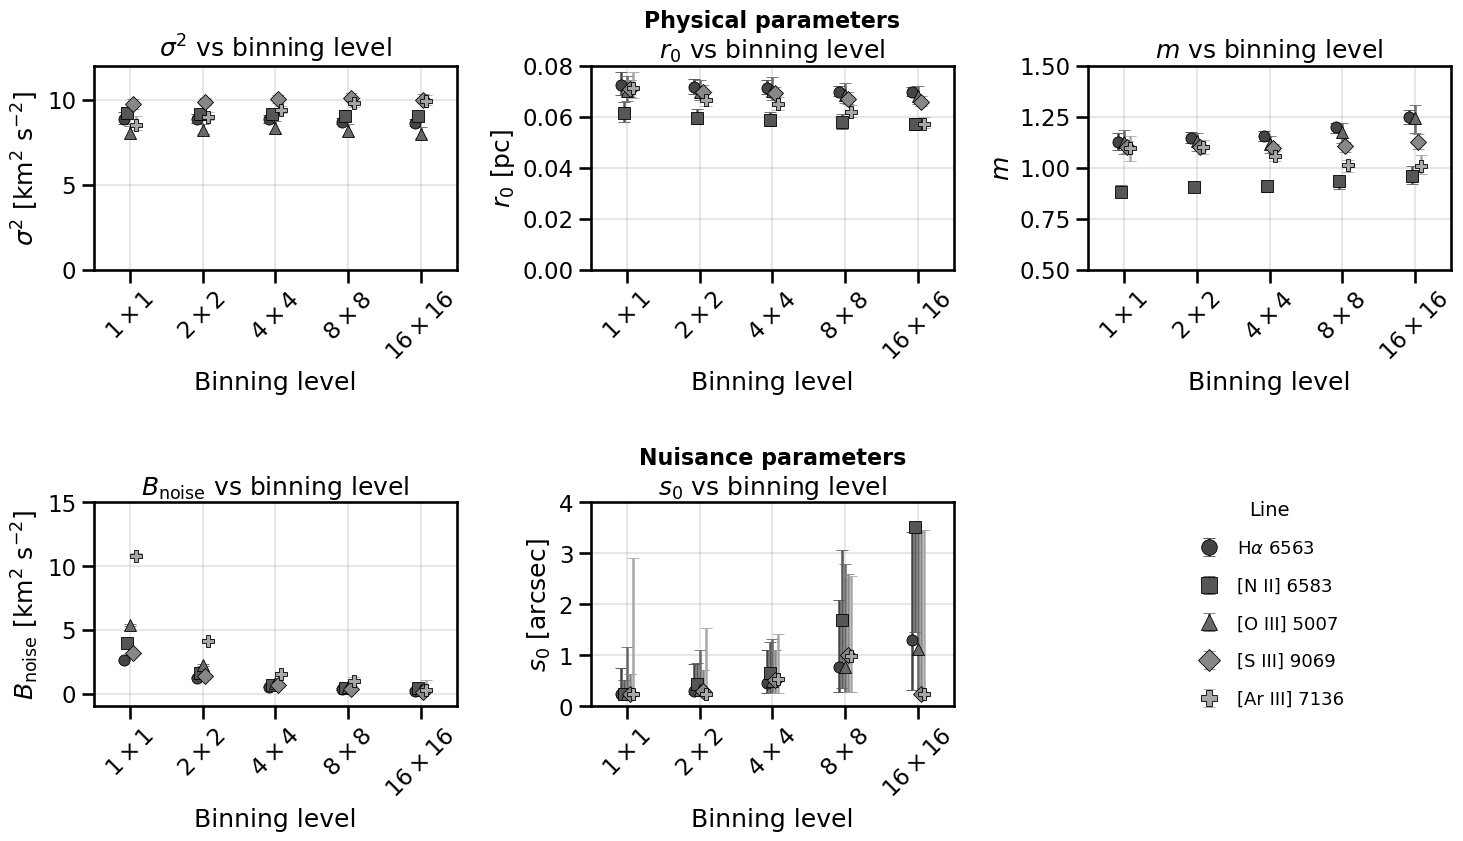

In [17]:
fig, axes = plot_param_grid_lines_bins(
    data_in,
    line_order=("H", "N", "O", "S", "Ar"),
    bin_levels=(0, 1, 2, 3, 4),
    xtick_labels=[
        r"$1 \times 1$",
        r"$2 \times 2$",
        r"$4 \times 4$",
        r"$8 \times 8$",
        r"$16 \times 16$",
    ],
    line_legend_labels=line_legend_labels,
    param_labels=param_labels,
    param_titles=param_titles,
    param_ylims=param_ylims,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    decimals=4,
    figsize=(15, 9),
    markersize=8,
    jitter=0.08,
    save=False,
    savepath="fit_parameters_grid_3.pdf",
)

# Comparison

In [18]:
def load_explicit_result_samples(
    results_comp,
    maps_dir,
    samples,
    *,
    read_header=True,
    fit_key="fit",
):
    """
    Load an explicit list of fit-result samples.

    This is useful when the samples are not organized as a regular
    line/bin grid.

    Parameters
    ----------
    results_comp : module
        Module that contains load_line_bundle_mat.

    maps_dir : str or pathlib.Path
        Directory where the result files are stored.

    samples : list of dict
        Explicit sample definitions.

        Each entry should have at least:

            {
                "file_name": "MUSE-M42-H-bin0",
                "label": "MUSE H0",
                "line": "H",
                "group": "MUSE"
            }

    read_header : bool
        Passed to results_comp.load_line_bundle_mat.

    fit_key : str
        Key used to access the fit table inside each loaded bundle.

    Returns
    -------
    data_in : list of dict
        Each entry contains:

            line
            label
            group
            file_name
            bundle
            fit
            fit_dict
            meta
    """

    data_in = []

    for sample in samples:
        file_name = sample["file_name"]
        label = sample.get("label", file_name)
        line = sample.get("line", None)
        group = sample.get("group", None)

        internal_name = sample.get(
            "internal_name",
            f"{label}_line".replace(" ", "_").replace("-", "_"),
        )

        bundle = results_comp.load_line_bundle_mat(
            file_name,
            internal_name,
            maps_dir,
            read_header=read_header,
        )

        fit = bundle[fit_key]
        fit_dict = fit.to_dict(orient="list")

        entry = {
            "line": line,
            "label": label,
            "group": group,
            "file_name": file_name,
            "bundle": bundle,
            "fit": fit,
            "fit_dict": fit_dict,
            "meta": bundle.get("meta", {}),
        }

        data_in.append(entry)

    return data_in

In [19]:
samples_explicit = [
    # ------------------------------------------------------------
    # KPNO original samples
    # ------------------------------------------------------------
    {
        "file_name": "KPNO-M42-H-bin0",
        "label": "KPNO H0",
        "line": "H",
        "group": "KPNO",
    },
    {
        "file_name": "KPNO-M42-O-bin0",
        "label": "KPNO O0",
        "line": "O",
        "group": "KPNO",
    },
    {
        "file_name": "KPNO-M42-N-bin0",
        "label": "KPNO N0",
        "line": "N",
        "group": "KPNO",
    },
    {
        "file_name": "KPNO-M42-S-bin0",
        "label": "KPNO S0",
        "line": "S",
        "group": "KPNO",
    },

    # ------------------------------------------------------------
    # MUSE trimmed samples
    # ------------------------------------------------------------
    {
        "file_name": "MUSE-M42-H-bin2_trim",
        "label": "MUSE H0 trim",
        "line": "H",
        "group": "MUSE trim",
    },
    {
        "file_name": "MUSE-M42-O-bin2_trim",
        "label": "MUSE O0 trim",
        "line": "O",
        "group": "MUSE trim",
    },
    {
        "file_name": "MUSE-M42-N-bin2_trim",
        "label": "MUSE N0 trim",
        "line": "N",
        "group": "MUSE trim",
    },

    # ------------------------------------------------------------
    # MUSE selected samples
    # ------------------------------------------------------------
    {
        "file_name": "MUSE-M42-H-bin2",
        "label": "MUSE H0",
        "line": "H",
        "group": "MUSE",
    },
    {
        "file_name": "MUSE-M42-N-bin2",
        "label": "MUSE N0",
        "line": "N",
        "group": "MUSE",
    },
    {
        "file_name": "MUSE-M42-S-bin2",
        "label": "MUSE S0",
        "line": "S2",
        "group": "MUSE",
    },
    {
        "file_name": "MUSE-M42-O-bin2",
        "label": "MUSE O1",
        "line": "O",
        "group": "MUSE",
    },
    {
        "file_name": "MUSE-M42-Ar-bin2",
        "label": "MUSE Ar2",
        "line": "Ar",
        "group": "MUSE",
    },
]

In [20]:
data_explicit = load_explicit_result_samples(
    results_comp,
    MAPS_DIR,
    samples_explicit,
    read_header=True,
)

In [21]:
def plot_param_grid_lines_as_x(
    data_in,
    *,
    params=("sig2", "r0", "m", "noise", "s0"),
    line_order=("H", "N", "O", "S", "S2", "Ar"),
    group_order=("KPNO", "MUSE trim", "MUSE"),
    line_labels=None,
    param_labels=None,
    param_titles=None,
    param_ylims=None,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    row_title_y=1.22,
    decimals=4,
    figsize=(15, 8),
    color_palette="Greys_d",
    markers=("o", "s", "^"),
    jitter=0.10,
    capsize=4,
    elinewidth=1.8,
    markersize=7,
    legend_fontsize=13,
    legend_title_fontsize=14,
    show_values=False,
    true=None,
    save=False,
    savepath="fit_parameters_lines_as_x.pdf",
):
    """
    Plot fit parameters with emission line on the x-axis.

    Layout
    ------
    First row:
        sig2, r0, m

    Second row:
        noise, s0, legend

    Encoding
    --------
    x-axis:
        emission line, e.g. H, N, O, S, S2, Ar

    marker/color:
        sample group, e.g. KPNO, MUSE trim, MUSE

    Expected data_in format
    -----------------------
    Each entry must contain:

        entry["line"]
        entry["group"]
        entry["fit_dict"]

    where fit_dict has entries like:

        fit_dict["sig2"] = [value, upper_error, lower_error]

    Parameters
    ----------
    line_labels : None, dict, list, or tuple
        Custom x-axis labels for emission lines.

        Example:
            line_labels = {
                "H": r"H$\\alpha$",
                "N": r"[N II]",
                "O": r"[O III]",
                "S": r"[S III]",
                "S2": r"[S II]",
                "Ar": r"[Ar III]",
            }

    param_labels : None or dict
        Custom y-axis labels with units.

        Example:
            param_labels = {
                "sig2": r"$\\sigma^2$ [km$^2$ s$^{-2}$]",
                "r0": r"$r_0$ [pc]",
                "m": r"$m$",
                "noise": r"$B_\\mathrm{noise}$ [km$^2$ s$^{-2}$]",
                "s0": r"$s_0$ [pc]",
            }

    param_titles : None or dict
        Custom subplot titles. If None, compact default titles are used.

    param_ylims : None or dict
        Custom y-axis limits for each parameter.

        Example:
            param_ylims = {
                "sig2": (0, 20),
                "r0": (0, 0.15),
                "m": (0.5, 2.0),
                "noise": (0, 2),
                "s0": (0, 0.02),
            }

    row_titles : tuple, list, or None
        Row titles for the first and second rows.

        Example:
            row_titles=("Physical parameters", "Nuisance parameters")

        If None, no row titles are added.
    """

    import numpy as np
    import seaborn as sns
    from matplotlib import pyplot as plt

    if len(data_in) == 0:
        raise ValueError("data_in is empty.")

    # ------------------------------------------------------------
    # Color and marker maps by group
    # ------------------------------------------------------------
    colors = sns.color_palette(
        color_palette,
        n_colors=len(group_order),
    )[::-1]

    color_map = {
        group: colors[i]
        for i, group in enumerate(group_order)
    }

    marker_map = {
        group: markers[i % len(markers)]
        for i, group in enumerate(group_order)
    }

    # Symmetric jitter offsets centered around zero
    if len(group_order) > 1:
        jitter_offsets = np.linspace(
            -jitter,
            jitter,
            len(group_order),
        )
    else:
        jitter_offsets = np.array([0.0])

    jitter_map = {
        group: jitter_offsets[i]
        for i, group in enumerate(group_order)
    }

    # ------------------------------------------------------------
    # x-axis positions for each emission line
    # ------------------------------------------------------------
    line_x = {
        line: i
        for i, line in enumerate(line_order)
    }

    if line_labels is None:
        line_labels_final = list(line_order)

    elif isinstance(line_labels, dict):
        line_labels_final = [
            line_labels.get(line, line)
            for line in line_order
        ]

    elif isinstance(line_labels, (list, tuple)):
        if len(line_labels) != len(line_order):
            raise ValueError(
                "If line_labels is a list/tuple, it must have the same "
                "length as line_order."
            )
        line_labels_final = list(line_labels)

    else:
        raise TypeError("line_labels must be None, a dict, list, or tuple.")

    # ------------------------------------------------------------
    # Parameter titles and y-axis labels
    # ------------------------------------------------------------
    default_param_titles = {
        "sig2": r"$\sigma^2$",
        "r0": r"$r_0$",
        "m": r"$m$",
        "noise": r"$B_\mathrm{noise}$",
        "s0": r"$s_0$",
    }

    default_param_labels = {
        "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
        "r0": r"$r_0$ [pc]",
        "m": r"$m$",
        "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
        "s0": r"$s_0$ [pc]",
    }

    if param_titles is None:
        param_titles_final = default_param_titles
    else:
        param_titles_final = {
            **default_param_titles,
            **param_titles,
        }

    if param_labels is None:
        param_labels_final = default_param_labels
    else:
        param_labels_final = {
            **default_param_labels,
            **param_labels,
        }

    # ------------------------------------------------------------
    # Y-axis limits
    # ------------------------------------------------------------
    if param_ylims is None:
        param_ylims_final = {}
    elif isinstance(param_ylims, dict):
        param_ylims_final = param_ylims
    else:
        raise TypeError("param_ylims must be None or a dictionary.")

    # ------------------------------------------------------------
    # Optional reference values
    # ------------------------------------------------------------
    if true is None:
        true_map = {}

    elif isinstance(true, dict):
        true_map = true

    elif isinstance(true, (list, tuple)):
        true_keys = ["sig2", "r0", "m"]
        true_map = {
            key: value
            for key, value in zip(true_keys, true)
        }

    else:
        raise TypeError("true must be None, a dict, list, or tuple.")

    # ------------------------------------------------------------
    # Figure layout
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        2,
        3,
        figsize=figsize,
        sharex=False,
    )

    axes = axes.ravel()

    param_to_axis = {
        "sig2": axes[0],
        "r0": axes[1],
        "m": axes[2],
        "noise": axes[3],
        "s0": axes[4],
    }

    # ------------------------------------------------------------
    # Main plotting loop
    # ------------------------------------------------------------
    for param in params:
        if param not in param_to_axis:
            continue

        ax = param_to_axis[param]

        for entry in data_in:
            fit_dict = entry["fit_dict"]
            line = entry.get("line", None)
            group = entry.get("group", None)

            if line not in line_x:
                continue

            if group not in group_order:
                continue

            if param not in fit_dict:
                continue

            value = round(float(fit_dict[param][0]), decimals)
            upper = max(0.0, round(float(fit_dict[param][1]), decimals))
            lower = max(0.0, round(float(fit_dict[param][2]), decimals))

            x = line_x[line] + jitter_map[group]

            ax.errorbar(
                x,
                value,
                yerr=[[lower], [upper]],
                fmt=marker_map[group],
                color=color_map[group],
                markerfacecolor=color_map[group],
                markeredgecolor="black",
                markeredgewidth=0.6,
                markersize=markersize,
                capsize=capsize,
                elinewidth=elinewidth,
                linestyle="none",
            )

            if show_values:
                ax.text(
                    x,
                    value,
                    f"{value:.{decimals}f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

        if param in true_map and true_map[param] is not None:
            ax.axhline(
                true_map[param],
                color="red",
                linestyle="--",
                linewidth=1.2,
                label="Reference",
            )

        ax.set_title(
            param_titles_final.get(param, param) + " vs emission line"
        )
        ax.set_ylabel(param_labels_final.get(param, param))
        ax.grid(alpha=0.3)

        # Apply custom y-axis range if requested
        if param in param_ylims_final and param_ylims_final[param] is not None:
            ax.set_ylim(param_ylims_final[param])

    # ------------------------------------------------------------
    # Common x-axis formatting
    # ------------------------------------------------------------
    x_positions = np.arange(len(line_order))

    for ax in axes[:5]:
        ax.set_xticks(x_positions)
        ax.set_xticklabels(line_labels_final, rotation=45)
        ax.set_xlim(-0.5, len(line_order) - 0.5)
        ax.set_xlabel("Emission line")

    # ------------------------------------------------------------
    # Row titles
    # ------------------------------------------------------------
    if row_titles is not None:
        if len(row_titles) != 2:
            raise ValueError("row_titles must contain exactly two entries.")

        axes[1].annotate(
            row_titles[0],
            xy=(0.5, row_title_y),
            xycoords="axes fraction",
            ha="center",
            va="center",
            fontsize=row_title_fontsize,
            fontweight="bold",
        )

        axes[4].annotate(
            row_titles[1],
            xy=(0.5, row_title_y),
            xycoords="axes fraction",
            ha="center",
            va="center",
            fontsize=row_title_fontsize,
            fontweight="bold",
        )

    # ------------------------------------------------------------
    # Legend in the empty sixth panel
    # ------------------------------------------------------------
    legend_ax = axes[5]
    legend_ax.axis("off")

    legend_handles = []

    used_groups = {
        entry.get("group", None)
        for entry in data_in
    }

    for group in group_order:
        if group not in used_groups:
            continue

        handle = plt.Line2D(
            [0],
            [0],
            marker=marker_map[group],
            color="none",
            markerfacecolor=color_map[group],
            markeredgecolor="black",
            markeredgewidth=0.6,
            markersize=markersize + 2,
            label=group,
        )

        legend_handles.append(handle)

    if len(legend_handles) > 0:
        legend_ax.legend(
            handles=legend_handles,
            loc="center",
            frameon=False,
            title="Sample",
            fontsize=legend_fontsize,
            title_fontsize=legend_title_fontsize,
            markerscale=1.4,
            handlelength=1.5,
            labelspacing=1.1,
        )

    fig.tight_layout()

    if save:
        fig.savefig(savepath, bbox_inches="tight")

    return fig, axes

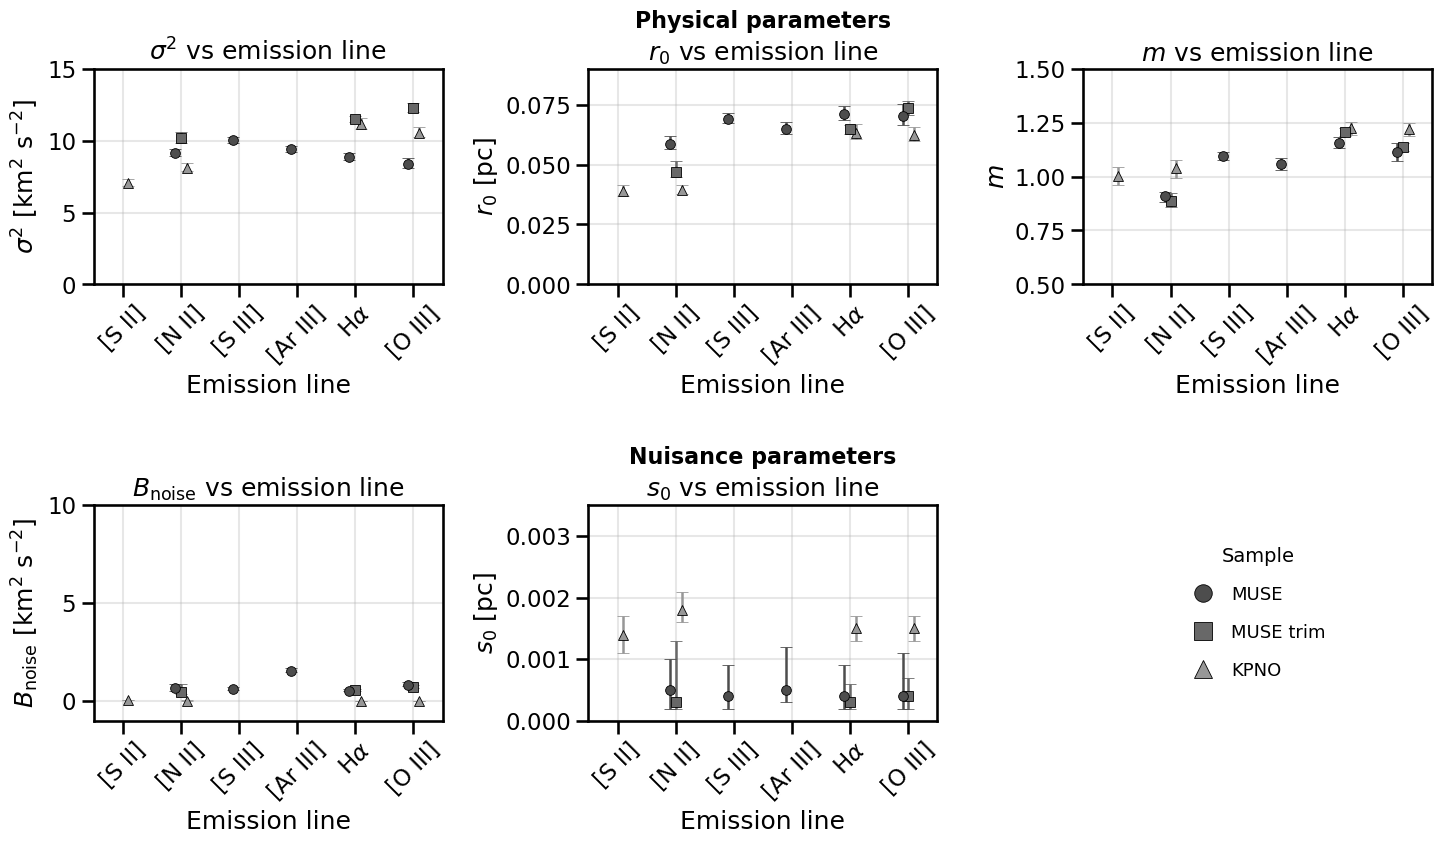

In [22]:

param_labels = {
    "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
    "r0": r"$r_0$ [pc]",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
    "s0": r"$s_0$ [pc]",
}

param_titles = {
    "sig2": r"$\sigma^2$",
    "r0": r"$r_0$",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$",
    "s0": r"$s_0$",
}


line_labels = {
    "H": r"H$\alpha$",
    "N": r"[N II]",
    "O": r"[O III]",
    "S": r"[S II]",
    "S2": r"[S III]",
    "Ar": r"[Ar III]",
}

param_ylims = {
    "sig2": (0, 15),
    "r0": (0, 0.09),
    "m": (0.5, 1.5),
    "noise": (-1, 10),
    "s0": (0, 0.0035),
}

fig, axes = plot_param_grid_lines_as_x(
    data_explicit,
    line_order=("S", "N", "S2", "Ar", "H", "O"),
    group_order=("MUSE", "MUSE trim","KPNO"),
    line_labels=line_labels,
    param_labels=param_labels,
    param_titles=param_titles,
    param_ylims=param_ylims,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    row_title_y=1.22,
    decimals=4,
    figsize=(15, 9),
    jitter=0.10,
    save=False,
    savepath="fit_parameters_grid_comparison_2.pdf",
)

In [23]:
for i in range(len(data_explicit)):
    pc = data_explicit[i]['meta']['PC']
    scale = 2.35 / pc

    old_value = data_explicit[i]['fit_dict']['s0'][0]
    old_upper = data_explicit[i]['fit_dict']['s0'][1]
    old_lower = data_explicit[i]['fit_dict']['s0'][2]

    new_value = max(0, old_value * scale)
    new_upper = old_upper * scale
    new_lower = old_lower * scale

    data_explicit[i]['fit_dict']['s0'] = [
        new_value,
        new_upper,
        new_lower,
    ]

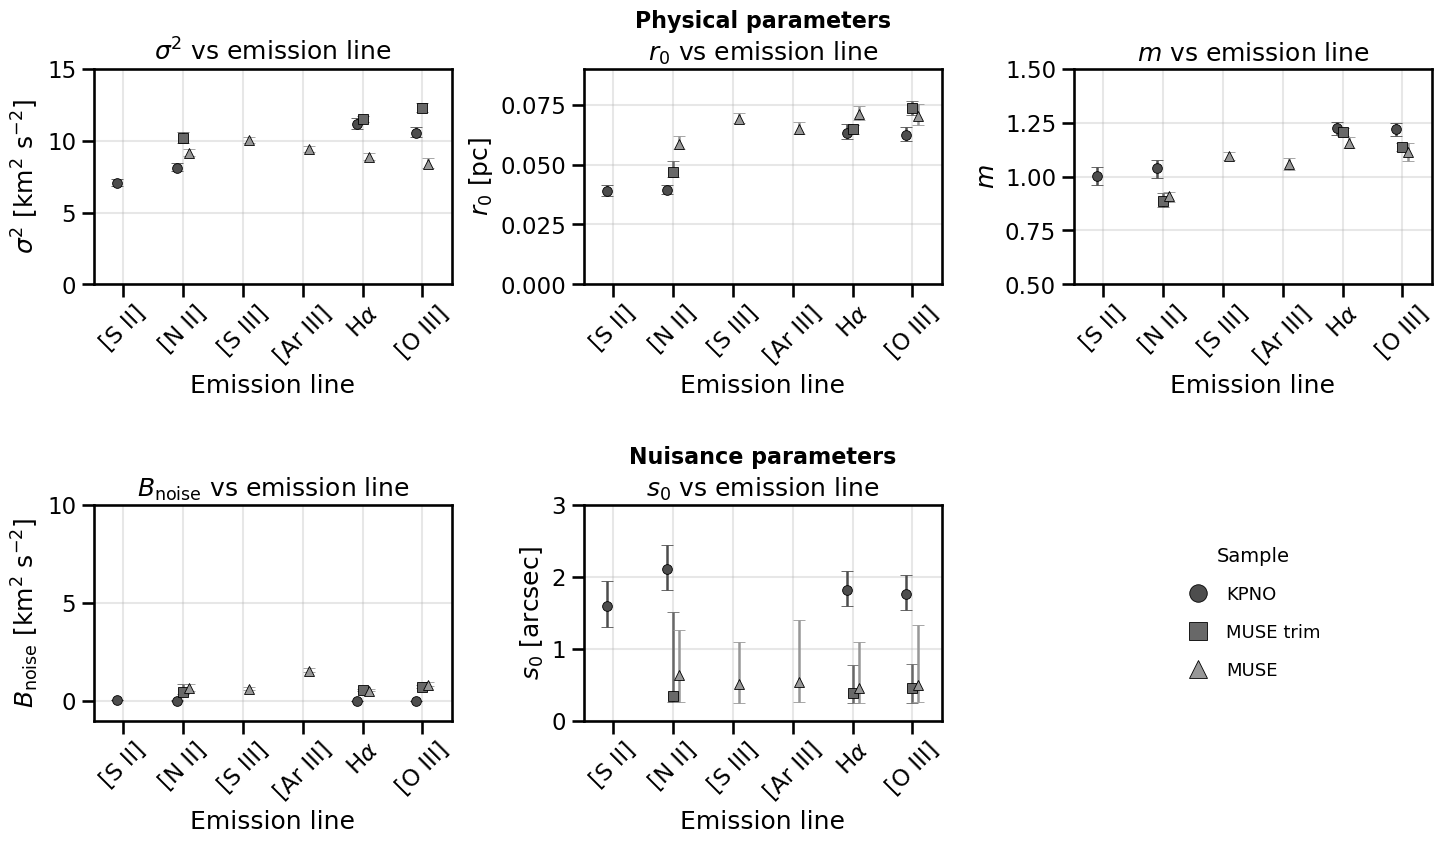

In [24]:
param_ylims = {
    "sig2": (0, 15),
    "r0": (0, 0.09),
    "m": (0.5, 1.5),
    "noise": (-1, 10),
    "s0": (0, 3),
}


param_labels = {
    "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
    "r0": r"$r_0$ [pc]",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
    "s0": r"$s_0$ [arcsec]",
}


fig, axes = plot_param_grid_lines_as_x(
    data_explicit,
    line_order=("S", "N", "S2", "Ar", "H", "O"),
    group_order=("KPNO", "MUSE trim", "MUSE"),
    line_labels=line_labels,
    param_labels=param_labels,
    param_titles=param_titles,
    param_ylims=param_ylims,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    row_title_y=1.22,
    decimals=4,
    figsize=(15, 9),
    jitter=0.10,
    save=False,
    savepath="fit_parameters_grid_comparison_4x4.pdf",
)

# 4 x 4

In [25]:
# ------------------------------------------------------------
# Fit-limit definitions
# ------------------------------------------------------------
fit_limits = (0.3, 0.4, 0.5, 0.6, 0.7)

line_order = ("H", "N", "O")

file_line_ids = {
    "H": "H",
    "N": "N",
    "O": "O",
}

# Labels used by plot_param_grid_lines_as_x as the "groups"
fit_limit_labels = {
    fit_limit: rf"$r_\mathrm{{max}} = {fit_limit:.1f}L$"
    for fit_limit in fit_limits
}

group_order = tuple(
    fit_limit_labels[fit_limit]
    for fit_limit in fit_limits
)


# ------------------------------------------------------------
# Construct the 15 explicit samples
# ------------------------------------------------------------
samples_explicit = []

for line in line_order:
    file_line = file_line_ids[line]

    for fit_limit in fit_limits:

        # 0.3 -> "03", 0.4 -> "04", etc.
        fit_tag = f"{int(round(10 * fit_limit)):02d}"

        file_name = (
            f"MUSE-M42-{file_line}-bin2_trim_{fit_tag}"
        )

        samples_explicit.append(
            {
                "file_name": file_name,
                "label": f"MUSE {line} trim {fit_tag}",
                "line": line,
                "group": fit_limit_labels[fit_limit],
                "fit_limit": fit_limit,
                "internal_name": (
                    f"MUSE_M42_{line}_bin2_trim_{fit_tag}"
                ),
            }
        )


# Optional: inspect the filenames before loading
for sample in samples_explicit:
    print(
        sample["line"],
        sample["fit_limit"],
        sample["file_name"],
    )

H 0.3 MUSE-M42-H-bin2_trim_03
H 0.4 MUSE-M42-H-bin2_trim_04
H 0.5 MUSE-M42-H-bin2_trim_05
H 0.6 MUSE-M42-H-bin2_trim_06
H 0.7 MUSE-M42-H-bin2_trim_07
N 0.3 MUSE-M42-N-bin2_trim_03
N 0.4 MUSE-M42-N-bin2_trim_04
N 0.5 MUSE-M42-N-bin2_trim_05
N 0.6 MUSE-M42-N-bin2_trim_06
N 0.7 MUSE-M42-N-bin2_trim_07
O 0.3 MUSE-M42-O-bin2_trim_03
O 0.4 MUSE-M42-O-bin2_trim_04
O 0.5 MUSE-M42-O-bin2_trim_05
O 0.6 MUSE-M42-O-bin2_trim_06
O 0.7 MUSE-M42-O-bin2_trim_07


In [26]:
fit_limit = sample.get("fit_limit", None)

In [27]:
def load_explicit_result_samples(
    results_comp,
    maps_dir,
    samples,
    *,
    read_header=True,
    fit_key="fit",
):
    """
    Load an explicit list of fit-result samples.
    """

    data_in = []

    for sample in samples:
        file_name = sample["file_name"]
        label = sample.get("label", file_name)
        line = sample.get("line")
        group = sample.get("group")
        fit_limit = sample.get("fit_limit")

        internal_name = sample.get(
            "internal_name",
            f"{label}_line".replace(" ", "_").replace("-", "_"),
        )

        bundle = results_comp.load_line_bundle_mat(
            file_name,
            internal_name,
            maps_dir,
            read_header=read_header,
        )

        fit = bundle[fit_key]
        fit_dict = fit.to_dict(orient="list")

        entry = {
            "line": line,
            "label": label,
            "group": group,
            "fit_limit": fit_limit,
            "file_name": file_name,
            "bundle": bundle,
            "fit": fit,
            "fit_dict": fit_dict,
            "meta": bundle.get("meta", {}),
        }

        data_in.append(entry)

    return data_in

In [28]:
data_fit_limits = load_explicit_result_samples(
    results_comp,
    MAPS_DIR,
    samples_explicit,
    read_header=True,
)

print(f"Successfully loaded {len(data_fit_limits)} samples")

Successfully loaded 15 samples


In [29]:
for entry in data_fit_limits:
    print(
        entry["line"],
        entry["fit_limit"],
        entry["file_name"],
        list(entry["fit"].columns),
    )

H 0.3 MUSE-M42-H-bin2_trim_03 ['sig2', 'r0', 'm', 's0', 'noise']
H 0.4 MUSE-M42-H-bin2_trim_04 ['sig2', 'r0', 'm', 's0', 'noise']
H 0.5 MUSE-M42-H-bin2_trim_05 ['sig2', 'r0', 'm', 's0', 'noise']
H 0.6 MUSE-M42-H-bin2_trim_06 ['sig2', 'r0', 'm', 's0', 'noise']
H 0.7 MUSE-M42-H-bin2_trim_07 ['sig2', 'r0', 'm', 's0', 'noise']
N 0.3 MUSE-M42-N-bin2_trim_03 ['sig2', 'r0', 'm', 's0', 'noise']
N 0.4 MUSE-M42-N-bin2_trim_04 ['sig2', 'r0', 'm', 's0', 'noise']
N 0.5 MUSE-M42-N-bin2_trim_05 ['sig2', 'r0', 'm', 's0', 'noise']
N 0.6 MUSE-M42-N-bin2_trim_06 ['sig2', 'r0', 'm', 's0', 'noise']
N 0.7 MUSE-M42-N-bin2_trim_07 ['sig2', 'r0', 'm', 's0', 'noise']
O 0.3 MUSE-M42-O-bin2_trim_03 ['sig2', 'r0', 'm', 's0', 'noise']
O 0.4 MUSE-M42-O-bin2_trim_04 ['sig2', 'r0', 'm', 's0', 'noise']
O 0.5 MUSE-M42-O-bin2_trim_05 ['sig2', 'r0', 'm', 's0', 'noise']
O 0.6 MUSE-M42-O-bin2_trim_06 ['sig2', 'r0', 'm', 's0', 'noise']
O 0.7 MUSE-M42-O-bin2_trim_07 ['sig2', 'r0', 'm', 's0', 'noise']


In [30]:
# ------------------------------------------------------------
# Plot labels and limits
# ------------------------------------------------------------
param_labels = {
    "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
    "r0": r"$r_0$ [pc]",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
    "s0": r"$s_0$ [pc]",
}

param_titles = {
    "sig2": r"$\sigma^2$",
    "r0": r"$r_0$",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$",
    "s0": r"$s_0$",
}

line_labels = {
    "N": r"[N II]",
    "H": r"H$\alpha$",
    "O": r"[O III]",
}

param_ylims = {
    "sig2": (0, 25),
    "r0": (0, 0.15),
    "m": (0.5, 1.5),
    "noise": (-1, 10),
    "s0": (0, 0.0035),
}

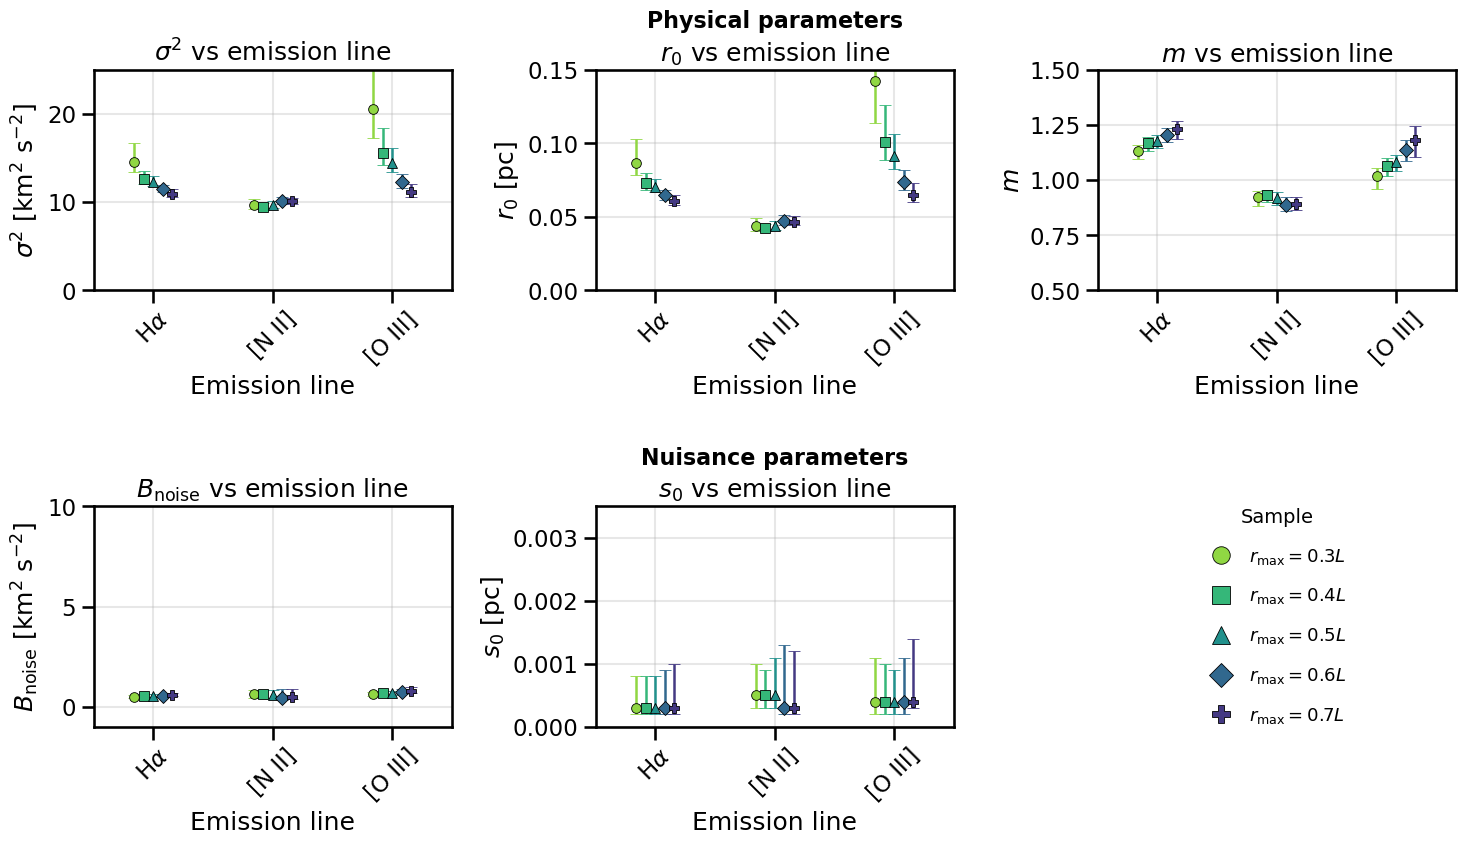

In [31]:
fig, axes = plot_param_grid_lines_as_x(
    data_fit_limits,

    # X-axis and legend order
    line_order=("H", "N", "O"),
    group_order=group_order,

    # Labels
    line_labels=line_labels,
    param_labels=param_labels,
    param_titles=param_titles,

    # Axis limits
    param_ylims=param_ylims,

    # Row labels
    row_titles=(
        "Physical parameters",
        "Nuisance parameters",
    ),
    row_title_fontsize=16,
    row_title_y=1.22,

    # Appearance
    decimals=4,
    figsize=(15, 9),
    color_palette="viridis",
    markers=("o", "s", "^", "D", "P"),
    jitter=0.16,
    capsize=4,
    elinewidth=1.8,
    markersize=7,

    # Output
    save=False,
    savepath="fit_parameters_fit_limit_comparison.pdf",
)

# Complete Sample

In [32]:
# Fractions used in the fitting-range analysis
fit_limits = ( 0.5, 0.6, 0.7)


# ------------------------------------------------------------
# KPNO original samples
# ------------------------------------------------------------
samples_kpno = [
    {
        "file_name": "KPNO-M42-H-bin0",
        "label": "KPNO H",
        "line": "H",
        "group": "KPNO",
    },
    {
        "file_name": "KPNO-M42-O-bin0",
        "label": "KPNO O",
        "line": "O",
        "group": "KPNO",
    },
    {
        "file_name": "KPNO-M42-N-bin0",
        "label": "KPNO N",
        "line": "N",
        "group": "KPNO",
    },
    {
        "file_name": "KPNO-M42-S-bin0",
        "label": "KPNO S",
        "line": "S",
        "group": "KPNO",
    },
]


# ------------------------------------------------------------
# MUSE-trim fitting-fraction samples
# ------------------------------------------------------------
samples_fit_fractions = []

for fit_limit in fit_limits:
    fit_tag = f"{int(round(10 * fit_limit)):02d}"
    group_label = rf"MUSE trim: $r_\max={fit_limit:.1f}L$"

    for line in ("H", "N", "O"):
        samples_fit_fractions.append(
            {
                "file_name": (
                    f"MUSE-M42-{line}-bin2_trim_{fit_tag}"
                ),
                "label": (
                    f"MUSE {line} trim, "
                    rf"$r_\max={fit_limit:.1f}L$"
                ),
                "line": line,
                "group": group_label,
                "fit_limit": fit_limit,
                "internal_name": (
                    f"MUSE_M42_{line}_bin2_trim_{fit_tag}"
                ),
            }
        )


# ------------------------------------------------------------
# MUSE full-field samples
# ------------------------------------------------------------
samples_muse = [
    {
        "file_name": "MUSE-M42-H-bin2",
        "label": "MUSE H",
        "line": "H",
        "group": "MUSE",
    },
    {
        "file_name": "MUSE-M42-N-bin2",
        "label": "MUSE N",
        "line": "N",
        "group": "MUSE",
    },
    {
        "file_name": "MUSE-M42-S-bin2",
        "label": "MUSE S III",
        "line": "S2",
        "group": "MUSE",
    },
    {
        "file_name": "MUSE-M42-O-bin2",
        "label": "MUSE O",
        "line": "O",
        "group": "MUSE",
    },
    {
        "file_name": "MUSE-M42-Ar-bin2",
        "label": "MUSE Ar",
        "line": "Ar",
        "group": "MUSE",
    },
]


# Combine all samples
samples_explicit = (
    samples_kpno
    + samples_fit_fractions
    + samples_muse
)

In [33]:
data_explicit = load_explicit_result_samples(
    results_comp,
    MAPS_DIR,
    samples_explicit,
    read_header=True,
)

print(f"Loaded {len(data_explicit)} samples")

Loaded 18 samples


In [34]:
fraction_groups = tuple(
    rf"MUSE trim: $r_\max={fit_limit:.1f}L$"
    for fit_limit in fit_limits
)

group_order = (
    "KPNO",
    *fraction_groups,
    "MUSE",
)

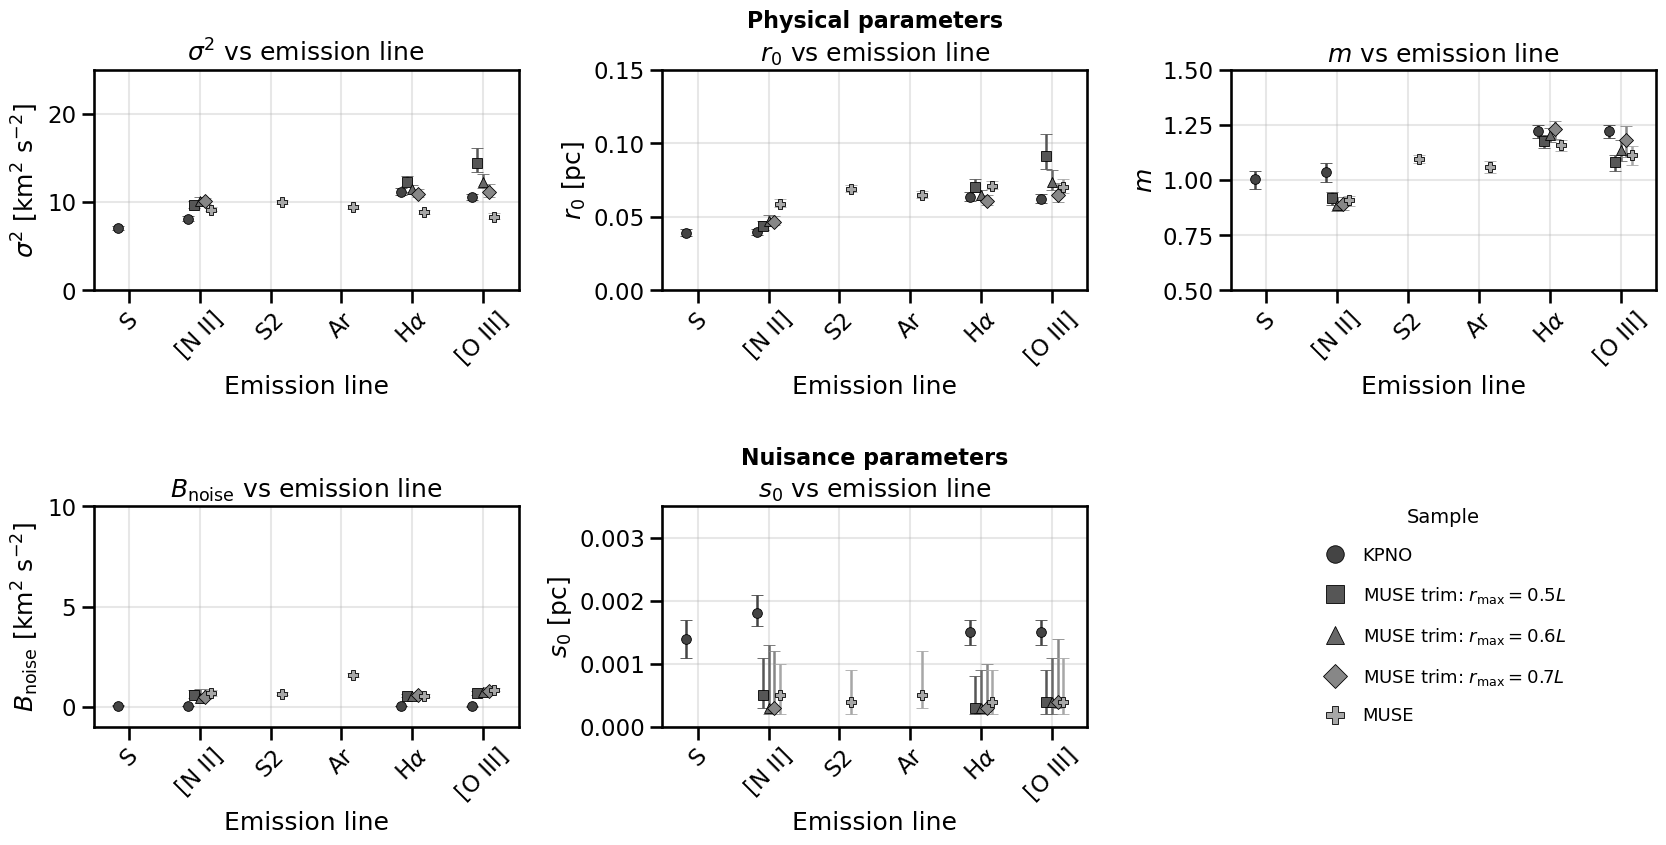

In [35]:
fig, axes = plot_param_grid_lines_as_x(
    data_explicit,
    line_order=("S", "N", "S2", "Ar", "H", "O"),
    group_order=group_order,
    line_labels=line_labels,
    param_labels=param_labels,
    param_titles=param_titles,
    param_ylims=param_ylims,
    row_titles=(
        "Physical parameters",
        "Nuisance parameters",
    ),
    row_title_fontsize=16,
    row_title_y=1.22,
    decimals=4,
    figsize=(17, 9),
 #   color_palette="viridis",
    markers=("o", "s", "^", "D", "P", "X", "v"),
    jitter=0.16,
    capsize=4,
    elinewidth=1.8,
    markersize=7,
    save=False,
    savepath="fit_parameters_with_fit_fractions.pdf",
)

In [36]:
import numpy as np
import pandas as pd

fit_limits=(0.5, 0.6, 0.7),
def average_trim_fit_results(
    data_in,
    *,
    params=("sig2", "r0", "m", "noise", "s0"),
    fit_limits=(0.5, 0.6, 0.7),
    line_order=("H", "N", "O"),
    group="MUSE trim",
):
    """
    Average the central values from the trim fitting-fraction results.

    For each emission line and parameter:

        central value = mean of the fitted values
        lower bound   = minimum(value - lower uncertainty)
        upper bound   = maximum(value + upper uncertainty)

    The uncertainties assigned to the averaged point extend from the
    average to these envelope limits.
    """

    averaged_entries = []

    for line in line_order:

        line_entries = [
            entry
            for entry in data_in
            if entry["line"] == line
            and any(
                np.isclose(entry.get("fit_limit"), limit)
                for limit in fit_limits
            )
        ]

        if not line_entries:
            print(f"No trim samples found for line {line}")
            continue

        fit_dict_average = {}

        for param in params:

            central_values = []
            lower_limits = []
            upper_limits = []

            for entry in line_entries:
                values = entry["fit_dict"].get(param)

                if values is None or len(values) < 3:
                    continue

                central = float(values[0])
                err_upper = float(values[1])
                err_lower = float(values[2])

                if not np.all(
                    np.isfinite([central, err_upper, err_lower])
                ):
                    continue

                central_values.append(central)
                lower_limits.append(central - err_lower)
                upper_limits.append(central + err_upper)

            if not central_values:
                fit_dict_average[param] = [np.nan, np.nan, np.nan]
                continue

            average_value = np.mean(central_values)

            envelope_lower = np.min(lower_limits)
            envelope_upper = np.max(upper_limits)

            average_err_lower = average_value - envelope_lower
            average_err_upper = envelope_upper - average_value

            # Required order:
            # [central value, upper uncertainty, lower uncertainty]
            fit_dict_average[param] = [
                average_value,
                average_err_upper,
                average_err_lower,
            ]

        # Reproduce the fit-table structure expected by the plotting code.
        fit_average = pd.DataFrame(fit_dict_average)

        averaged_entries.append(
            {
                "line": line,
                "label": f"MUSE {line} trim average",
                "group": group,
                "file_name": None,
                "fit_limit": None,
                "fit_limits_used": tuple(
                    entry.get("fit_limit")
                    for entry in line_entries
                ),
                "bundle": None,
                "fit": fit_average,
                "fit_dict": fit_dict_average,
                "meta": {
                    "aggregation": "mean with full CI envelope",
                    "n_samples": len(line_entries),
                },
            }
        )

    return averaged_entries

In [37]:
data_trim_average = average_trim_fit_results(
    data_fit_limits,
    params=("sig2", "r0", "m", "noise", "s0"),
    line_order=("H", "N", "O"),
)

print(f"Created {len(data_trim_average)} averaged trim points")

Created 3 averaged trim points


In [38]:
for entry in data_trim_average:
    print(f"\n{entry['line']} — {entry['label']}")

    for param, values in entry["fit_dict"].items():
        central, err_upper, err_lower = values

        print(
            f"{param:6s}: "
            f"{central:.4f} "
            f"+{err_upper:.4f} "
            f"-{err_lower:.4f}"
        )


H — MUSE H trim average
sig2  : 11.5710 +1.3448 -0.9608
r0    : 0.0653 +0.0102 -0.0073
m     : 1.2041 +0.0656 -0.0577
noise : 0.5591 +0.1373 -0.0699
s0    : 0.0003 +0.0007 -0.0001

N — MUSE N trim average
sig2  : 9.9974 +0.6035 -0.6268
r0    : 0.0459 +0.0055 -0.0044
m     : 0.8995 +0.0479 -0.0415
noise : 0.5129 +0.3827 -0.1513
s0    : 0.0004 +0.0009 -0.0001

O — MUSE O trim average
sig2  : 12.6413 +3.4675 -2.0335
r0    : 0.0766 +0.0295 -0.0166
m     : 1.1337 +0.1108 -0.0928
noise : 0.7442 +0.2312 -0.1311
s0    : 0.0004 +0.0010 -0.0002


In [39]:
rows = []

for entry in data_trim_average:
    for param, values in entry["fit_dict"].items():
        central, err_upper, err_lower = values

        rows.append(
            {
                "line": entry["line"],
                "parameter": param,
                "mean": central,
                "err_lower": err_lower,
                "err_upper": err_upper,
                "lower_limit": central - err_lower,
                "upper_limit": central + err_upper,
            }
        )

df_trim_average = pd.DataFrame(rows)

df_trim_average

,line,parameter,mean,err_lower,err_upper,lower_limit,upper_limit
0,H,sig2,11.571045,0.960821,1.344788,10.610224,12.915832
1,H,r0,0.065314,0.007270,0.010158,0.058043,0.075472
2,H,m,1.204113,0.057653,0.065625,1.146460,1.269737
3,H,noise,0.559078,0.069938,0.137302,0.489140,0.696379
4,H,s0,0.000329,0.000118,0.000712,0.000211,0.001041
5,N,sig2,9.997365,0.626798,0.603462,9.370566,10.600827
6,N,r0,0.045878,0.004393,0.005538,0.041485,0.051416
7,N,m,0.899464,0.041458,0.047949,0.858007,0.947413
8,N,noise,0.512914,0.151286,0.382712,0.361628,0.895626
9,N,s0,0.000358,0.000141,0.000928,0.000217,0.001286


In [40]:
samples_base = samples_kpno + samples_muse

data_base = load_explicit_result_samples(
    results_comp,
    MAPS_DIR,
    samples_base,
    read_header=True,
)

In [41]:
data_explicit_average = (
    data_base
    + data_trim_average
)

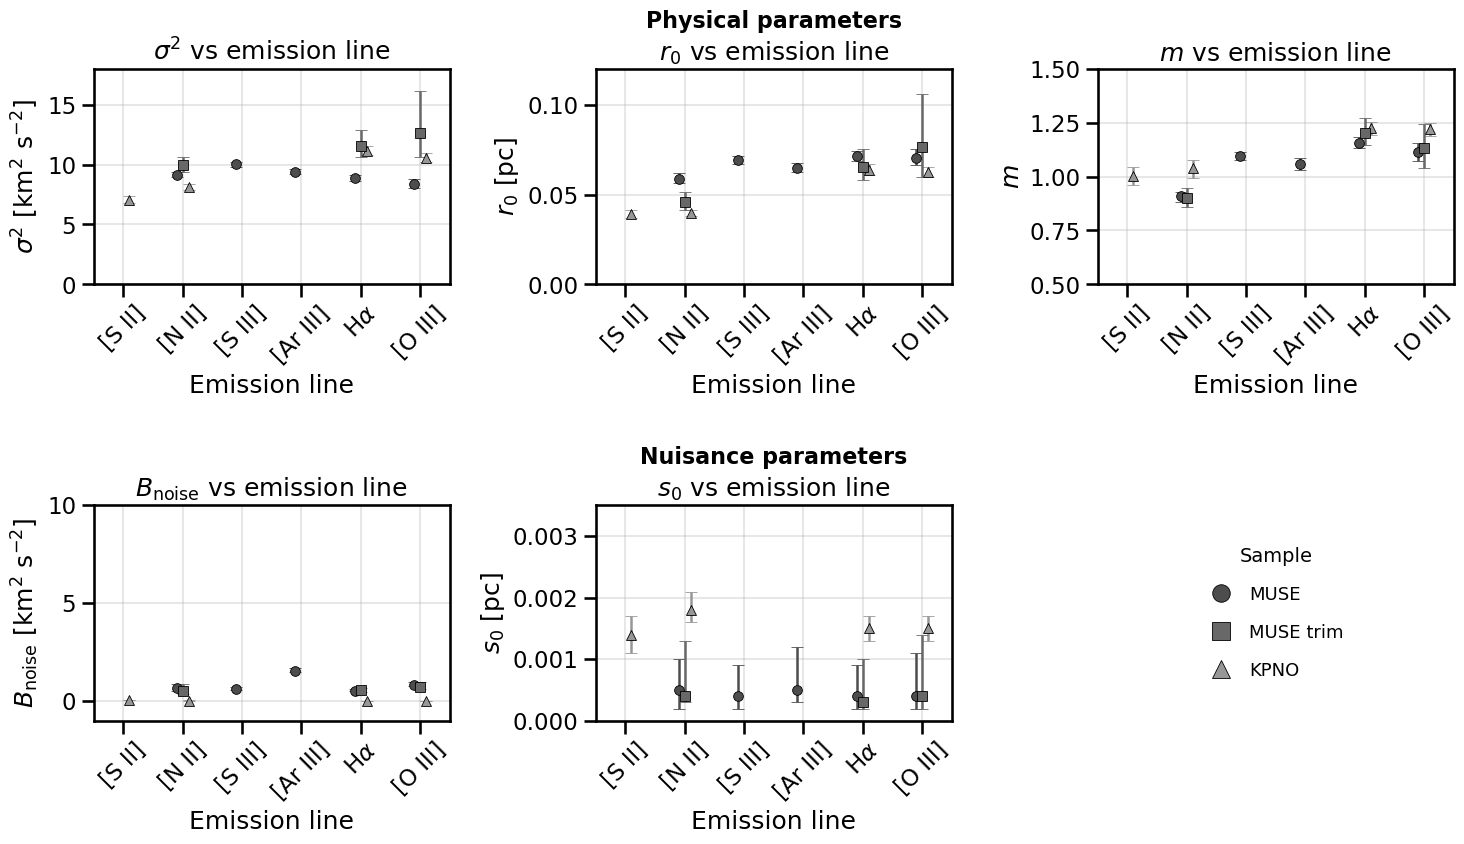

In [42]:
param_ylims = {
    "sig2": (0, 18),
    "r0": (0, 0.12),
    "m": (0.5, 1.5),
    "noise": (-1, 10),
    "s0": (0, 0.0035),
}

line_labels = {
    "H": r"H$\alpha$",
    "N": r"[N II]",
    "O": r"[O III]",
    "S": r"[S II]",
    "S2": r"[S III]",
    "Ar": r"[Ar III]",
}

fig, axes = plot_param_grid_lines_as_x(
    data_explicit_average,
    line_order=("S", "N", "S2", "Ar", "H", "O"),
    group_order=( "MUSE", "MUSE trim", "KPNO"),
    line_labels=line_labels,
    param_labels=param_labels,
    param_titles=param_titles,
    param_ylims=param_ylims,
    row_titles=(
        "Physical parameters",
        "Nuisance parameters",
    ),
    row_title_fontsize=16,
    row_title_y=1.22,
    decimals=4,
    figsize=(15, 9),
    color_palette="Greys_d",
    markers=("o", "s", "^"),
    jitter=0.10,
    capsize=4,
    elinewidth=1.8,
    markersize=7,
    save=False,
    savepath="fit_parameters_trim_average_envelope.pdf",
)

In [43]:
import copy
import numpy as np


def convert_s0_to_arcsec(data_in):
    """
    Return a copy of data_in with s0 converted to arcseconds.

    Conversion:
        s0_arcsec = s0_original * (2.35 / PC)

    The stored order is:
        [central value, upper uncertainty, lower uncertainty]
    """

    data_out = copy.deepcopy(data_in)

    for entry in data_out:
        pc = float(entry["meta"]["PC"])
        scale = 2.35 / pc

        s0_value, s0_upper, s0_lower = entry["fit_dict"]["s0"]

        converted_s0 = [
            max(0.0, float(s0_value) * scale),
            float(s0_upper) * scale,
            float(s0_lower) * scale,
        ]

        # Update both representations
        entry["fit_dict"]["s0"] = converted_s0
        entry["fit"]["s0"] = converted_s0

        # Record the conversion
        entry["meta"]["s0_unit"] = "arcsec"
        entry["meta"]["s0_conversion_scale"] = scale

    return data_out

In [44]:
data_fit_limits_arcsec = convert_s0_to_arcsec(
    data_fit_limits
)

In [45]:
data_trim_average = average_trim_fit_results(
    data_fit_limits_arcsec,
    fit_limits=(0.5, 0.6, 0.7),
)

In [46]:
samples_base = samples_kpno + samples_muse

data_base = load_explicit_result_samples(
    results_comp,
    MAPS_DIR,
    samples_base,
    read_header=True,
)

data_base_arcsec = convert_s0_to_arcsec(data_base)

In [47]:
data_explicit_average = (
    data_base_arcsec
    + data_trim_average
)

In [48]:
param_ylims = {
    "sig2": (0, 18),
    "r0": (0, 0.125),
    "m": (0.5, 1.5),
    "noise": (-1, 10),
    "s0": (0, 3),
}

param_labels = {
    "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
    "r0": r"$r_0$ [pc]",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
    "s0": r"$s_0$ [arcsec]",
}

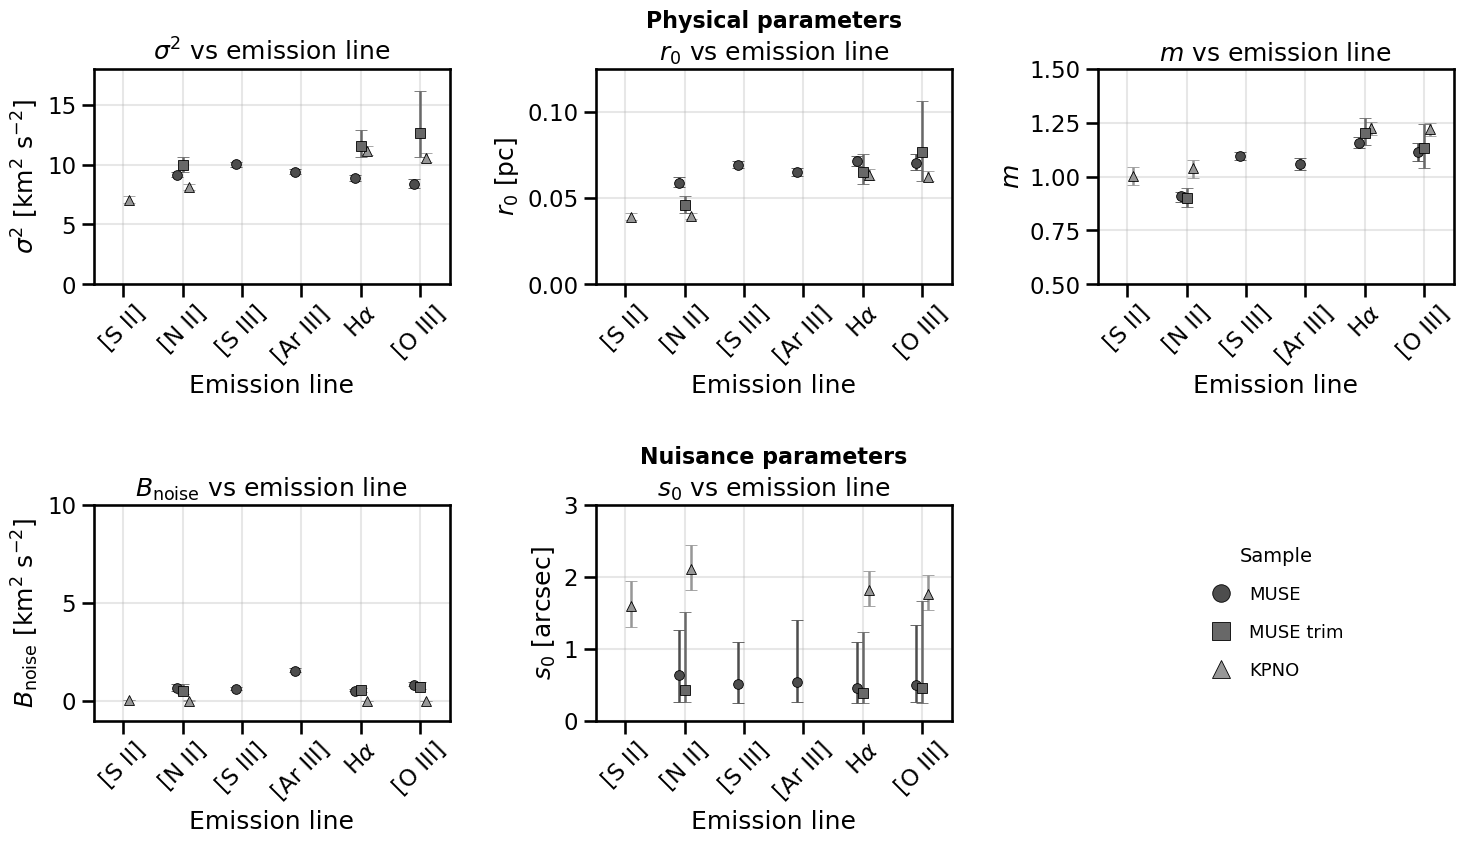

In [49]:
fig, axes = plot_param_grid_lines_as_x(
    data_explicit_average,
    line_order=("S", "N", "S2", "Ar", "H", "O"),
    group_order=( "MUSE", "MUSE trim", "KPNO"),
    line_labels=line_labels,
    param_labels=param_labels,
    param_titles=param_titles,
    param_ylims=param_ylims,
    row_titles=("Physical parameters", "Nuisance parameters"),
    row_title_fontsize=16,
    row_title_y=1.22,
    decimals=4,
    figsize=(15, 9),
    jitter=0.10,
    save=True,
    savepath="fit_parameters_trim_average_envelope.pdf",
)

In [56]:
data_explicit_average[10]

{'line': 'N',
 'label': 'MUSE N trim average',
 'group': 'MUSE trim',
 'file_name': None,
 'fit_limit': None,
 'fit_limits_used': (0.5, 0.6, 0.7),
 'bundle': None,
 'fit':        sig2        r0         m     noise        s0
 0  9.997365  0.045878  0.899464  0.512914  0.423614
 1  0.603462  0.005538  0.047949  0.382712  1.097291
 2  0.626798  0.004393  0.041458  0.151286  0.167275,
 'fit_dict': {'sig2': [9.997364853017748,
   0.6034621887603642,
   0.6267983651221023],
  'r0': [0.045877969419937555, 0.005537618246828885, 0.004392736518892791],
  'm': [0.8994642072327096, 0.04794879264192342, 0.04145755273712015],
  'noise': [0.5129141572769425, 0.38271219140312696, 0.15128596227044555],
  's0': [0.4236141976388554, 1.0972907968123438, 0.1672753969979564]},
 'meta': {'aggregation': 'mean with full CI envelope', 'n_samples': 3}}

In [80]:
def print_fit_summary_row(results):
    L   = 0.45
    pc  = 0.002   # [pc / arcsec]
    pix = 0.2  # Instrument resolution [arcsec / pix]
    #binsize = results['meta']['BINSIZE'] # [pix]
    FWHM = 1 #conversion to FWHM was done previously

    sig2, sig2_plus, sig2_minus = results['fit']['sig2']
    m, m_plus, m_minus = results['fit']['m']
    r0, r0_plus, r0_minus = results['fit']['r0']
    s0, s0_plus, s0_minus = results['fit']['s0']
    noise, noise_plus, noise_minus = results['fit']['noise']

    row = " & ".join([
        f"{sig2:.2f}\\PM{{{sig2_plus:.2f}}}{{{sig2_minus:.2f}}}",
        f"{r0:.3f}\\PM{{{r0_plus:.3f}}}{{{r0_minus:.3f}}}",
        f"{m:.2f}\\PM{{{m_plus:.2f}}}{{{m_minus:.2f}}}",
        f"{noise:.3f}\\PM{{{noise_plus:.3f}}}{{{noise_minus:.3f}}}",
        #f"{s0:.2f}\\PM{{{s0_plus:.2f}}}{{{s0_minus:.2f}}}",
        f"<{((s0 + s0_plus)):.2f}",
        #f"{L:.2f}",
        f"{(2*sig2/noise)**0.5:.2f}",
        #f"{L/r0:.2f}",
        f"{((s0*pc)/2.355)/r0:.4f}",
        #f"{s0 * FWHM:.2f}\\PM{{{s0_plus * FWHM:.2f}}}{{{s0_minus * FWHM:.2f}}}",
    ])

    print(row)
    #print(f"noise      = {(noise + noise_plus):.2f} (km/s)^2")
    #print(f"s0(rms)    = {(s0 + s0_plus):.4f} pc")
    print(f"s0(FWHM)   = {((s0 + s0_plus)):.2f} arcsec")
    #print(f"Binsize/r0 = {(pc*pix*2**binsize)/r0:.2f}" )

In [81]:
for index in (9, 10, 11):
    print_fit_summary_row(data_explicit_average[index])

11.57\PM{1.34}{0.96} & 0.065\PM{0.010}{0.007} & 1.20\PM{0.07}{0.06} & 0.559\PM{0.137}{0.070} & <1.23 & 6.43 & 0.0051
s0(FWHM)   = 1.23 arcsec
10.00\PM{0.60}{0.63} & 0.046\PM{0.006}{0.004} & 0.90\PM{0.05}{0.04} & 0.513\PM{0.383}{0.151} & <1.52 & 6.24 & 0.0078
s0(FWHM)   = 1.52 arcsec
12.64\PM{3.47}{2.03} & 0.077\PM{0.030}{0.017} & 1.13\PM{0.11}{0.09} & 0.744\PM{0.231}{0.131} & <1.67 & 5.83 & 0.0050
s0(FWHM)   = 1.67 arcsec
